In [1]:
h5_file = "LOC_Os08g39890.h5"


In [2]:
import sys
import os
import numpy as np
import pandas as pd

import h5py

import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

from scipy.ndimage import gaussian_filter1d

import seaborn as sns

import matplotlib.cm as cm
import matplotlib.colors as colors

import matplotlib as mpl
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib import gridspec
from matplotlib.ticker import FormatStrFormatter

#Helper function to draw a letter at a given position
def dna_letter_at(letter, x, y, yscale=1, ax=None, color=None, alpha=1.0):

    #Define letter heights and colors
    fp = FontProperties(family="DejaVu Sans", weight="bold")
    globscale = 1.35
    LETTERS = {	"T" : TextPath((-0.305, 0), "T", size=1, prop=fp),
                "G" : TextPath((-0.384, 0), "G", size=1, prop=fp),
                "A" : TextPath((-0.35, 0), "A", size=1, prop=fp),
                "C" : TextPath((-0.366, 0), "C", size=1, prop=fp),
                "UP" : TextPath((-0.488, 0), '$\\Uparrow$', size=1, prop=fp),
                "DN" : TextPath((-0.488, 0), '$\\Downarrow$', size=1, prop=fp),
                "(" : TextPath((-0.25, 0), "(", size=1, prop=fp),
                "." : TextPath((-0.125, 0), "-", size=1, prop=fp),
                ")" : TextPath((-0.1, 0), ")", size=1, prop=fp)}
    COLOR_SCHEME = {'G': 'orange',#'orange', 
                    'A': 'green',#'red', 
                    'C': 'blue',#'blue', 
                    'T': 'red',#'darkgreen',
                    'UP': 'green', 
                    'DN': 'red',
                    '(': 'black',
                    '.': 'black', 
                    ')': 'black'}


    text = LETTERS[letter]

    #Choose color
    chosen_color = COLOR_SCHEME[letter]
    if color is not None :
        chosen_color = color

    #Draw letter onto axis
    t = mpl.transforms.Affine2D().scale(1*globscale, yscale*globscale) + \
        mpl.transforms.Affine2D().translate(x,y) + ax.transData
    p = PathPatch(text, lw=0, fc=chosen_color, alpha=alpha, transform=t)
    if ax != None:
        ax.add_artist(p)
    
    return p

#Function to plot sequence logo
def plot_seq_scores(importance_scores, figsize=(16, 2), plot_y_ticks=True, y_min=None, y_max=None, save_figs=False, fig_name="default", center_marker=False, remove_spines=False) :

    importance_scores = importance_scores.T

    fig = plt.figure(figsize=figsize)
    
    ref_seq = ""
    
    #Loop over reference sequence letters
    for j in range(importance_scores.shape[1]) :
        argmax_nt = np.argmax(np.abs(importance_scores[:, j]))
        
        if argmax_nt == 0 :
            ref_seq += "A"
        elif argmax_nt == 1 :
            ref_seq += "C"
        elif argmax_nt == 2 :
            ref_seq += "G"
        elif argmax_nt == 3 :
            ref_seq += "T"

    

    ax = plt.gca()
    if remove_spines:
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)

    if center_marker:
        center_x = len(ref_seq) / 2
        plt.axvline(x=center_x, color='red', linestyle='--', linewidth=1)

    #Loop over reference sequence letters and draw
    for i in range(0, len(ref_seq)) :
        mutability_score = np.sum(importance_scores[:, i])
        color = None
        dna_letter_at(ref_seq[i], i + 0.5, 0, mutability_score, ax, color=color)
    
    plt.sca(ax)
    plt.xticks([], [])
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    
    plt.xlim((0, len(ref_seq)))
    
    #plt.axis('off')
    
    if plot_y_ticks :
        plt.yticks(fontsize=12)
    else :
        plt.yticks([], [])
    
    #Set axis limits
    if y_min is not None and y_max is not None :
        plt.ylim(y_min, y_max)
    elif y_min is not None :
        plt.ylim(y_min)
    else :
        plt.ylim(
            np.min(importance_scores) - 0.1 * np.max(np.abs(importance_scores)),
            np.max(importance_scores) + 0.1 * np.max(np.abs(importance_scores))
        )
    
    plt.axhline(y=0., color='black', linestyle='-', linewidth=1)

    #for axis in fig.axes :
    #    axis.get_xaxis().set_visible(False)
    #    axis.get_yaxis().set_visible(False)

    plt.tight_layout()

    if save_figs :
        plt.savefig(fig_name + ".png", transparent=True, dpi=300)
        plt.savefig(fig_name + ".eps")

    plt.show()


In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

with h5py.File(h5_file, 'r') as f:
    print("Datasets in HDF5 file:")
    print("=" * 50)
    
    for key in f.keys():
        dataset = f[key]
        print(f"{key:12s}: {dataset.shape} {dataset.dtype}")
        
        # Show some example data
        if key in ['gene', 'chr', 'strand']:
            print(f"             Example: {dataset[:3]}")
        elif key in ['start', 'end']:
            print(f"             Example: {dataset[:3]}")
        print()

Datasets in HDF5 file:
chr         : (1,) |S1
             Example: [b'8']

end         : (1,) int64
             Example: [25294957]

gene        : (1,) |S14
             Example: [b'LOC_Os08g39890']

grads       : (1, 32768, 4, 23) float16

grads_saliency: (1, 32768, 4, 23) float16

seqs        : (1, 32768, 4) bool

start       : (1,) int64
             Example: [25262189]

strand      : (1,) |S1
             Example: [b'-']



In [4]:
with h5py.File("LOC_Os08g39890.h5", "r") as f:
    grads = f["grads"][:]
grads[0, :, :, :]

array([[[ 4.6253e-05,  1.3411e-05,  1.8346e-04, ...,  3.0041e-05,
          3.8147e-06, -3.4571e-06],
        [-2.4915e-05, -4.3333e-05, -8.8811e-05, ..., -9.1791e-06,
         -1.4544e-05, -1.1921e-06],
        [-5.5432e-05, -2.4617e-05, -1.6248e-04, ..., -1.9252e-05,
         -1.3065e-04, -1.9431e-05],
        [ 3.3975e-05,  5.4598e-05,  6.7830e-05, ..., -1.6689e-06,
          1.4138e-04,  2.4080e-05]],

       [[-7.2002e-05,  1.8942e-04,  7.7188e-05, ...,  1.4305e-05,
          6.0737e-05,  1.4007e-05],
        [-8.7619e-06, -1.1194e-04, -1.1003e-04, ..., -2.3246e-05,
         -2.7061e-05, -1.4663e-05],
        [-3.2902e-05,  5.4300e-05, -6.4373e-05, ...,  8.1062e-06,
         -1.4126e-05, -1.2159e-05],
        [ 1.1373e-04, -1.3185e-04,  9.7215e-05, ...,  8.9407e-07,
         -1.9550e-05,  1.2755e-05]],

       [[ 9.2685e-05,  1.4424e-04,  3.3283e-04, ...,  5.9843e-05,
          7.1704e-05,  6.9141e-06],
        [-1.0550e-04, -6.9499e-05, -3.1495e-04, ..., -3.8862e-05,
         -1.

In [5]:
tissues_dict = {
    0: "A_7-10day_Root",
    1: "B_7-10day_Seedlings",
    2: "C_2lday_BasalShoot",
    3: "D_28day_BasalShoot",
    4: "E_Node1-2F",
    5: "F_40day_leaf",
    6: "G_Grain_filling",
    7: "H_Internodel-2",
    8: "I_Tillering_bud",
    9: "J_top2ndLeaf",
    10: "K_top2ndLeafDown",
    11: "L_top2ndLeafDusk",
    12: "M_LittlePanicle",
    13: "N_panicle_shoot",
    14: "P_young_panicle",
    15: "Q_flag_leaf_atHeadingDate",
    16: "R_Pistil",
    17: "S_SAM",
    18: "T_Stamen",
    19: "U_5DAFseed",
    20: "W_10DAFseed",
    21: "X_GerminatingRootBud",
    22: "Y_LeafProtoplast"
}
import json
with open("23tissues_dict.json", "w") as f:
    # multiple rows
    json.dump(tissues_dict, f, indent=4)

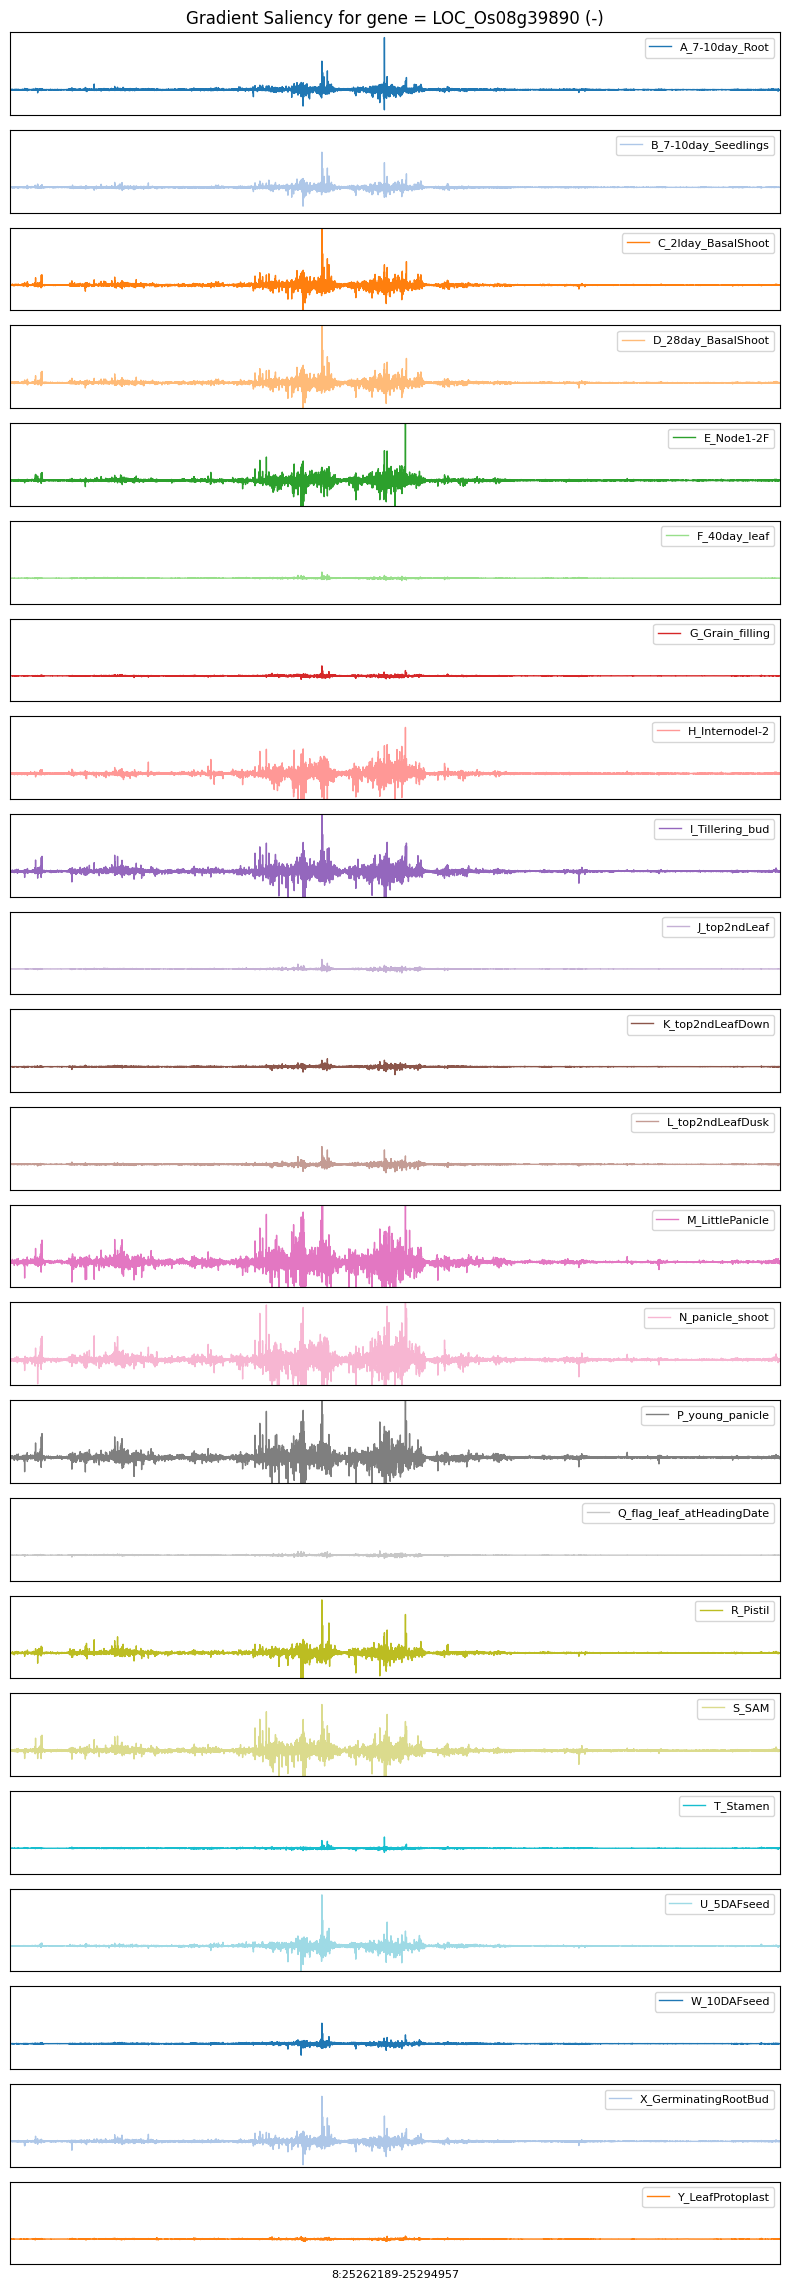

In [6]:

use_gaussian = True
min_padding = 4096
gaussian_sigma = 8
logo_width = 192

with h5py.File(h5_file, 'r') as f:
    grads_saliency = f['grads_saliency'][:]
    gene_id = f['gene'][0].decode('utf-8')
    strand = f['strand'][0].decode('utf-8')
    start = f['start'][0]
    end = f['end'][0]
    chr = f['chr'][0].decode('utf-8')

n_tissue = len(grads_saliency[0, 0, 0, :])
f, ax = plt.subplots(n_tissue, 1, figsize=(8, n_tissue * 1))
tissue_colors = sns.color_palette("tab20", n_tissue)
min_val = np.min(grads_saliency[0, :, :, 0])
max_val = np.max(grads_saliency[0, :, :, 0])
#min_val = np.min(np.sum(grads_saliency[0, :, :, 0], axis=-1))
#max_val = np.max(np.sum(grads_saliency[0, :, :, 0], axis=-1))
max_abs_val = max(np.abs(min_val), np.abs(max_val))
min_val -= 0.1 * max_abs_val
max_val += 0.1 * max_abs_val

for ti in range(n_tissue):
    score = grads_saliency[0, :, :, ti]
    l1 = ax[ti].plot(np.arange(score.shape[0]), np.sum(score, axis=-1), linewidth=1, color=tissue_colors[ti], label=tissues_dict[ti])
    plt.sca(ax[ti])
    plt.xlim(0, score.shape[0])
    plt.ylim(min_val, max_val)
    plt.legend(handles=[l1[0]], fontsize=8)
    plt.yticks([],[])
    plt.xticks([],[])

plt.sca(ax[0])
plt.title(f"Gradient Saliency for gene = {gene_id} ({strand})")
plt.sca(ax[n_tissue-1])
plt.xlabel(f"{chr}:{start}-{end}", fontsize=8)
plt.sca(plt.gca())
plt.tight_layout()
plt.show()

In [16]:
# Sepcify the main tissue to compare with others
main_tissue_ix = 0

Tissue B_7-10day_Seedlings	: Spearman correlation = 0.5173582383080697
Tissue C_2lday_BasalShoot	: Spearman correlation = 0.5312304994743113
Tissue D_28day_BasalShoot	: Spearman correlation = 0.5219139978895779
Tissue E_Node1-2F	: Spearman correlation = 0.19550088080908645
Tissue F_40day_leaf	: Spearman correlation = 0.10554117412092992
Tissue G_Grain_filling	: Spearman correlation = 0.34196951241380563
Tissue H_Internodel-2	: Spearman correlation = 0.10863674239709536
Tissue I_Tillering_bud	: Spearman correlation = 0.4217192784055226
Tissue J_top2ndLeaf	: Spearman correlation = 0.1411282055608098
Tissue K_top2ndLeafDown	: Spearman correlation = 0.19073712312909966
Tissue L_top2ndLeafDusk	: Spearman correlation = 0.309570844063476
Tissue M_LittlePanicle	: Spearman correlation = 0.09610328773966016
Tissue N_panicle_shoot	: Spearman correlation = 0.2298075839810076
Tissue P_young_panicle	: Spearman correlation = 0.19482907232501853
Tissue Q_flag_leaf_atHeadingDate	: Spearman correlation 

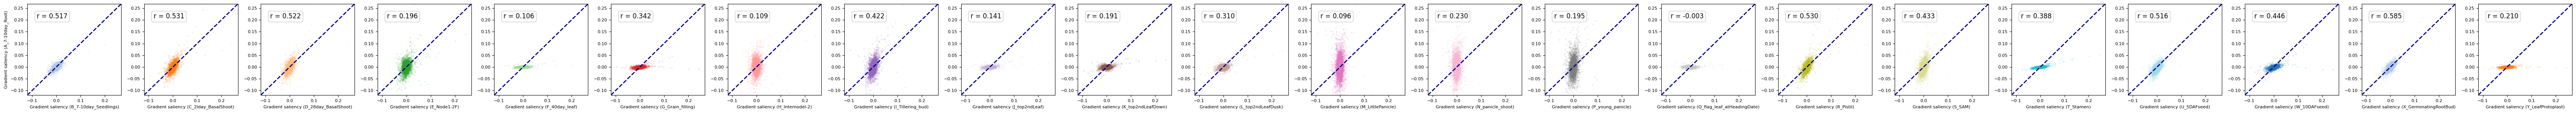

In [17]:
f ,ax = plt.subplots(1, n_tissue - 1, figsize=( (n_tissue - 1) * 3, 3))
ax_ix = 0
for ti in range(n_tissue):
    if ti != main_tissue_ix :
        main_score = grads_saliency[0, :, :, main_tissue_ix]
        other_score = grads_saliency[0, :, :, ti]
        r_val, _ = spearmanr(np.sum(main_score, axis=-1), np.sum(other_score, axis=-1))
        print(f"Tissue {tissues_dict[ti]}\t: Spearman correlation = {r_val}")
        ax[ax_ix].scatter(np.sum(main_score, axis=-1), np.sum(other_score, axis=-1), s=4, color=tissue_colors[ti], alpha=0.1)
        ax[ax_ix].plot([min_val, max_val], [min_val, max_val], linewidth=2, linestyle='--', color='darkblue')
        plt.sca(ax[ax_ix])
        plt.xlim(min_val, max_val)
        plt.ylim(min_val, max_val)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        plt.xlabel(f"Gradient saliency ({tissues_dict[ti]})", fontsize=8)

        ax[ax_ix].text(
            0.10,0.90, f"r = {r_val:.3f}", transform=ax[ax_ix].transAxes, 
            fontsize=12, ha='left', va='top', 
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.8)
)
        ax_ix += 1
plt.sca(ax[0])
plt.ylabel(f"Gradient saliency ({tissues_dict[main_tissue_ix]})", fontsize=8)
plt.sca(plt.gca())
plt.tight_layout()
plt.savefig(f"{tissues_dict[main_tissue_ix]}_Against_Others_Grads_{gene_id}.pdf", dpi=300)
plt.show()



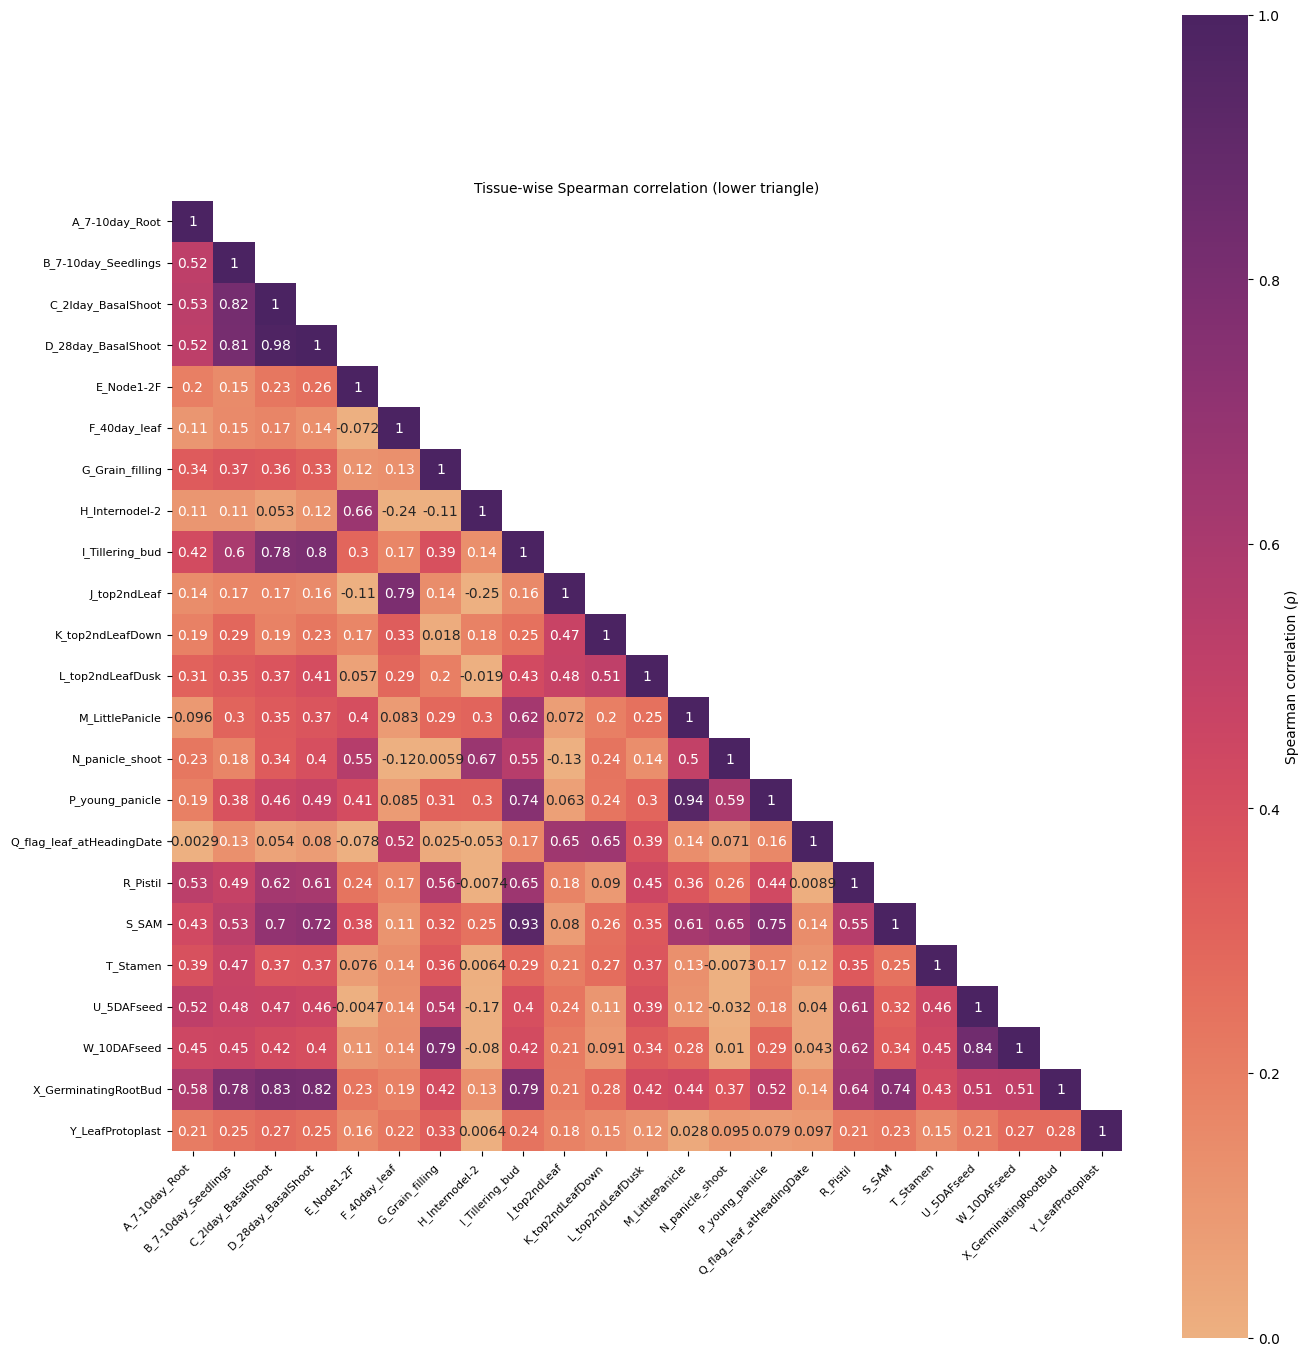

Saved heatmap to: Spearman_Heatmap_LowerTriangle_LOC_Os08g39890.pdf


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# === 1) 计算 Spearman 矩阵 ===
tissue_vectors = []
for ti in range(n_tissue):
    vec = np.sum(grads_saliency[0, :, :, ti], axis=-1)
    tissue_vectors.append(vec)
tissue_vectors = np.asarray(tissue_vectors)

R = np.eye(n_tissue)
for i in range(n_tissue):
    for j in range(i+1, n_tissue):
        x, y = tissue_vectors[i], tissue_vectors[j]
        mask_valid = np.isfinite(x) & np.isfinite(y)
        if np.sum(mask_valid) >= 2:
            r, _ = spearmanr(x[mask_valid], y[mask_valid])
        else:
            r = np.nan
        R[i, j] = r
        R[j, i] = r

labels = [tissues_dict[ti] for ti in range(n_tissue)]

# === 2) 保留下三角（含对角线），屏蔽上三角 ===
mask = np.triu(np.ones_like(R, dtype=bool), k=1)

# === 3) 画热图 ===
plt.figure(figsize=(max(6, n_tissue*0.6), max(5, n_tissue*0.6)))
sns.heatmap(
    R,
    mask=mask,
    cmap=sns.color_palette("flare", as_cmap=True),
    vmin=0, vmax=1,
    square=True,
    annot=True,   # 🚫 不显示数值
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "Spearman correlation (ρ)"}
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.title("Tissue-wise Spearman correlation (lower triangle)", fontsize=10)
plt.tight_layout()

out_path = f"Spearman_Heatmap_LowerTriangle_{gene_id}.pdf"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved heatmap to: {out_path}")

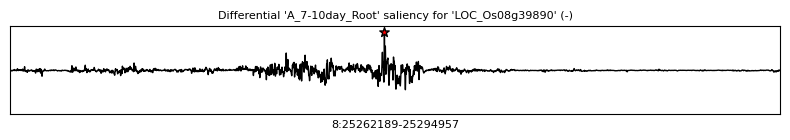

Max pos (rel) = 15933
Max pos (abs) = 25278122


In [ ]:
main_score = grads_saliency[0, :, :, main_tissue_ix]
others_avg_score = np.mean(grads_saliency[0, :, :, np.arange(n_tissue) != main_tissue_ix], axis=0)
diff_score = np.sum(main_score - others_avg_score, axis=-1)

if use_gaussian :
    diff_score = gaussian_filter1d(diff_score.astype('float32'), sigma=gaussian_sigma, truncate=2).astype('float16')

max_pos = np.argmax(diff_score[min_padding:-min_padding]) + min_padding
min_pos = np.argmin(diff_score[min_padding:-min_padding]) + min_padding
max_val = np.max(diff_score[min_padding:-min_padding])
min_val = np.min(diff_score[min_padding:-min_padding])
max_abs_val = max(np.abs(max_val), np.abs(min_val))

plt.figure(figsize=(8, 1.5))
plt.plot(np.arange(diff_score.shape[0]), diff_score, color='black', linewidth=1, linestyle='-')
plt.scatter([max_pos], [max_val], color='red', marker='*', s=50, linewidth=1, edgecolor='black', zorder=1000)
plt.xlim(0, diff_score.shape[0])
plt.ylim(-max_abs_val*1.15, max_abs_val*1.15)
plt.xticks([], [])
plt.yticks([], [])
plt.title(f"Differential '{tissues_dict[main_tissue_ix]}' saliency for '{gene_id}' ({strand})", fontsize=8)
plt.xlabel(f"{chr}:{start}-{end}", fontsize=8)
plt.tight_layout()
plt.savefig(f"{tissues_dict[main_tissue_ix]}_Diff_Grads_{gene_id}.pdf", dpi=300)
plt.show()
print("Max pos (rel) = " + str(max_pos))
print("Max pos (abs) = " + str(start + max_pos))


y_min = -0.48260742
y_max = 0.25335938
chr: 8:25262189-25294957
A_7-10day_Root


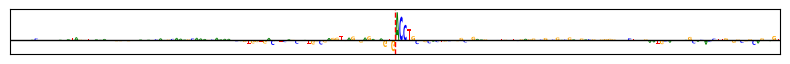

B_7-10day_Seedlings


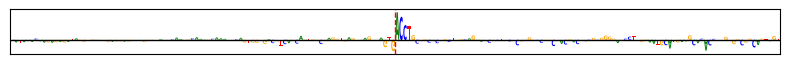

C_2lday_BasalShoot


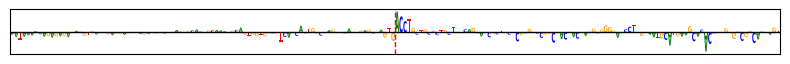

D_28day_BasalShoot


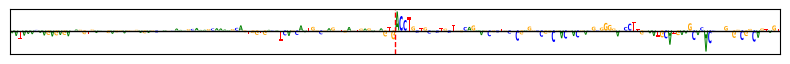

E_Node1-2F


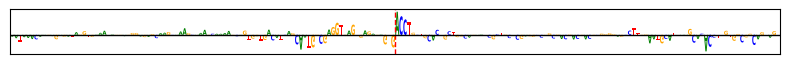

F_40day_leaf


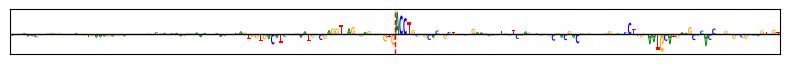

G_Grain_filling


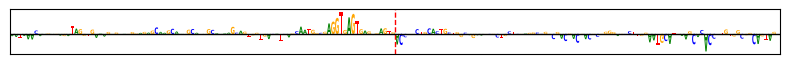

H_Internodel-2


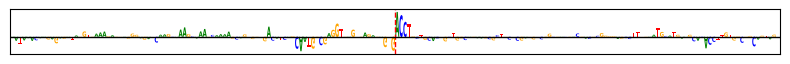

I_Tillering_bud


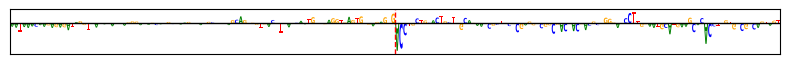

J_top2ndLeaf


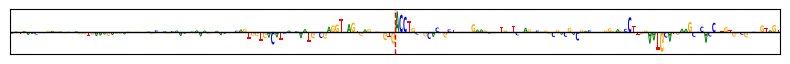

K_top2ndLeafDown


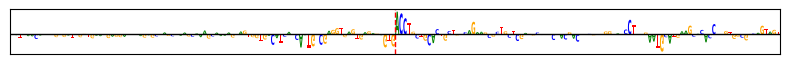

L_top2ndLeafDusk


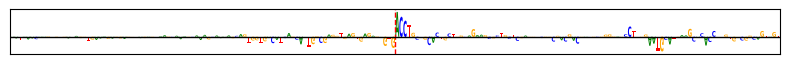

M_LittlePanicle


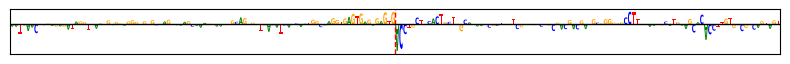

N_panicle_shoot


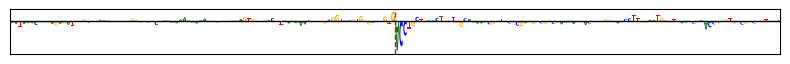

P_young_panicle


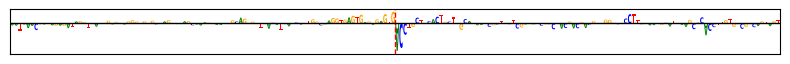

Q_flag_leaf_atHeadingDate


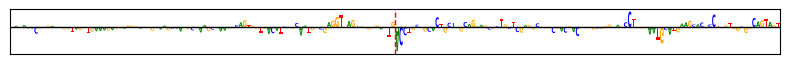

R_Pistil


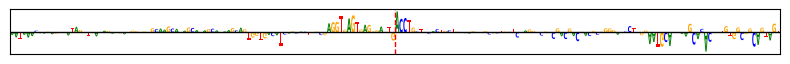

S_SAM


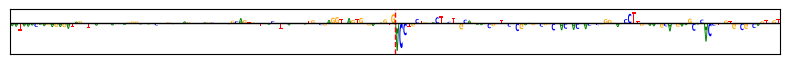

T_Stamen


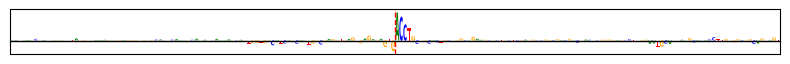

U_5DAFseed


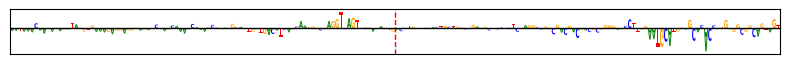

W_10DAFseed


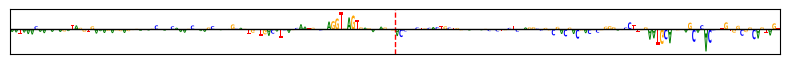

X_GerminatingRootBud


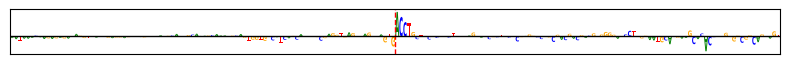

Y_LeafProtoplast


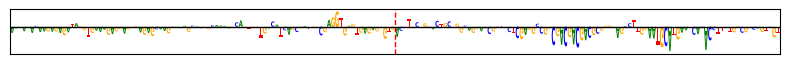

In [46]:
plot_start = max_pos - logo_width // 2
plot_end = max_pos + logo_width // 2

min_logo_val = np.min(grads_saliency[0, plot_start:plot_end, :, :])
max_logo_val = np.max(grads_saliency[0, plot_start:plot_end, :, :])
max_abs_logo_val = max(np.abs(min_logo_val), np.abs(max_logo_val))

min_logo_val -= 0.02 * max_abs_logo_val
max_logo_val += 0.02 * max_abs_logo_val

print("y_min = " + str(round(min_logo_val, 8)))
print("y_max = " + str(round(max_logo_val, 8)))
print(f"chr: {chr}:{start}-{end}")
for ti in range(n_tissue) :
    print(tissues_dict[ti])

    score = grads_saliency[0, plot_start:plot_end, :, ti]

    plot_seq_scores(
        score,
        y_min=None, # min_logo_val
        y_max=None, # max_logo_val
        figsize=(8, 0.75),
        plot_y_ticks=False,
        save_figs=False,
        fig_name=f"{tissues_dict[ti]}_Grads_{gene_id}.pdf",
        remove_spines=False,
        center_marker=True
    )